In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
DATASET_PATH = "dataset"
CSV_PATH = os.path.join(DATASET_PATH, "english.csv")
IMG_PATH = os.path.join(DATASET_PATH, "Img")

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (3410, 2)

Columns:
['image', 'label']

First 5 rows:


,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [3]:
IMG_SIZE = 28

X = []
y = []

for _, row in df.iterrows():
    image_path = os.path.join(DATASET_PATH, row["image"])
    
    img = Image.open(image_path).convert("L")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    
    X.append(np.array(img))
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

print("Image data shape:", X.shape)
print("Labels shape:", y.shape)
print("Number of classes:", len(np.unique(y)))

Image data shape: (3410, 28, 28)
Labels shape: (3410,)
Number of classes: 62


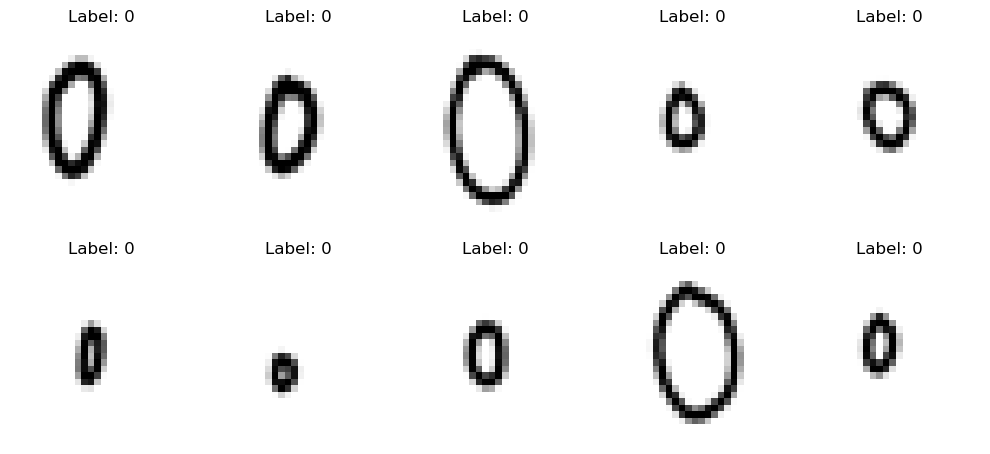

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Flatten each 28x28 image into 784 features
X = X.reshape(X.shape[0], -1)

# Normalize pixel values from [0, 255] to [0, 1]
X = X.astype("float32") / 255.0

print("Final feature shape:", X.shape)
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Final feature shape: (3410, 784)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of classes:", len(label_encoder.classes_))
print("Classes:", label_encoder.classes_)

Training samples: 2728
Testing samples: 682
Number of classes: 62
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


In [7]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.errors = []

    def step(self, z):
        return 1 if z >= 0 else 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors = []

        for epoch in range(self.epochs):
            errors = 0

            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = self.step(linear_output)

                update = self.learning_rate * (y[i] - prediction)

                self.weights += update * X[i]
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

        return self

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)

In [8]:
classes = np.unique(y_train)

pla_models = {}

for cls in classes:
    print(f"Training PLA for class {label_encoder.inverse_transform([cls])[0]}...")
    
    binary_y = (y_train == cls).astype(int)
    
    model = Perceptron(learning_rate=0.01, epochs=20)
    model.fit(X_train, binary_y)
    
    pla_models[cls] = model

print("\nPLA training completed.")

Training PLA for class 0...
Training PLA for class 1...
Training PLA for class 2...
Training PLA for class 3...
Training PLA for class 4...
Training PLA for class 5...
Training PLA for class 6...
Training PLA for class 7...
Training PLA for class 8...
Training PLA for class 9...
Training PLA for class A...
Training PLA for class B...
Training PLA for class C...
Training PLA for class D...
Training PLA for class E...
Training PLA for class F...
Training PLA for class G...
Training PLA for class H...
Training PLA for class I...
Training PLA for class J...
Training PLA for class K...
Training PLA for class L...
Training PLA for class M...
Training PLA for class N...
Training PLA for class O...
Training PLA for class P...
Training PLA for class Q...
Training PLA for class R...
Training PLA for class S...
Training PLA for class T...
Training PLA for class U...
Training PLA for class V...
Training PLA for class W...
Training PLA for class X...
Training PLA for class Y...
Training PLA for cla

In [9]:
def pla_predict(X, models):
    scores = []

    for cls in sorted(models.keys()):
        model = models[cls]
        score = np.dot(X, model.weights) + model.bias
        scores.append(score)

    scores = np.array(scores).T
    
    return np.array(sorted(models.keys()))[np.argmax(scores, axis=1)]


y_pred_pla = pla_predict(X_test, pla_models)

print("Predictions generated.")
print("Number of predictions:", len(y_pred_pla))

Predictions generated.
Number of predictions: 682


In [10]:
pla_accuracy = accuracy_score(y_test, y_pred_pla)

pla_precision = precision_score(
    y_test, y_pred_pla, average="macro", zero_division=0
)

pla_recall = recall_score(
    y_test, y_pred_pla, average="macro", zero_division=0
)

pla_f1 = f1_score(
    y_test, y_pred_pla, average="macro", zero_division=0
)

pla_results = pd.DataFrame({
    "Model": ["PLA"],
    "Accuracy": [pla_accuracy],
    "Precision": [pla_precision],
    "Recall": [pla_recall],
    "F1-Score": [pla_f1]
})

display(pla_results)

,Model,Accuracy,Precision,Recall,F1-Score
0,PLA,0.136364,0.176802,0.136364,0.102543


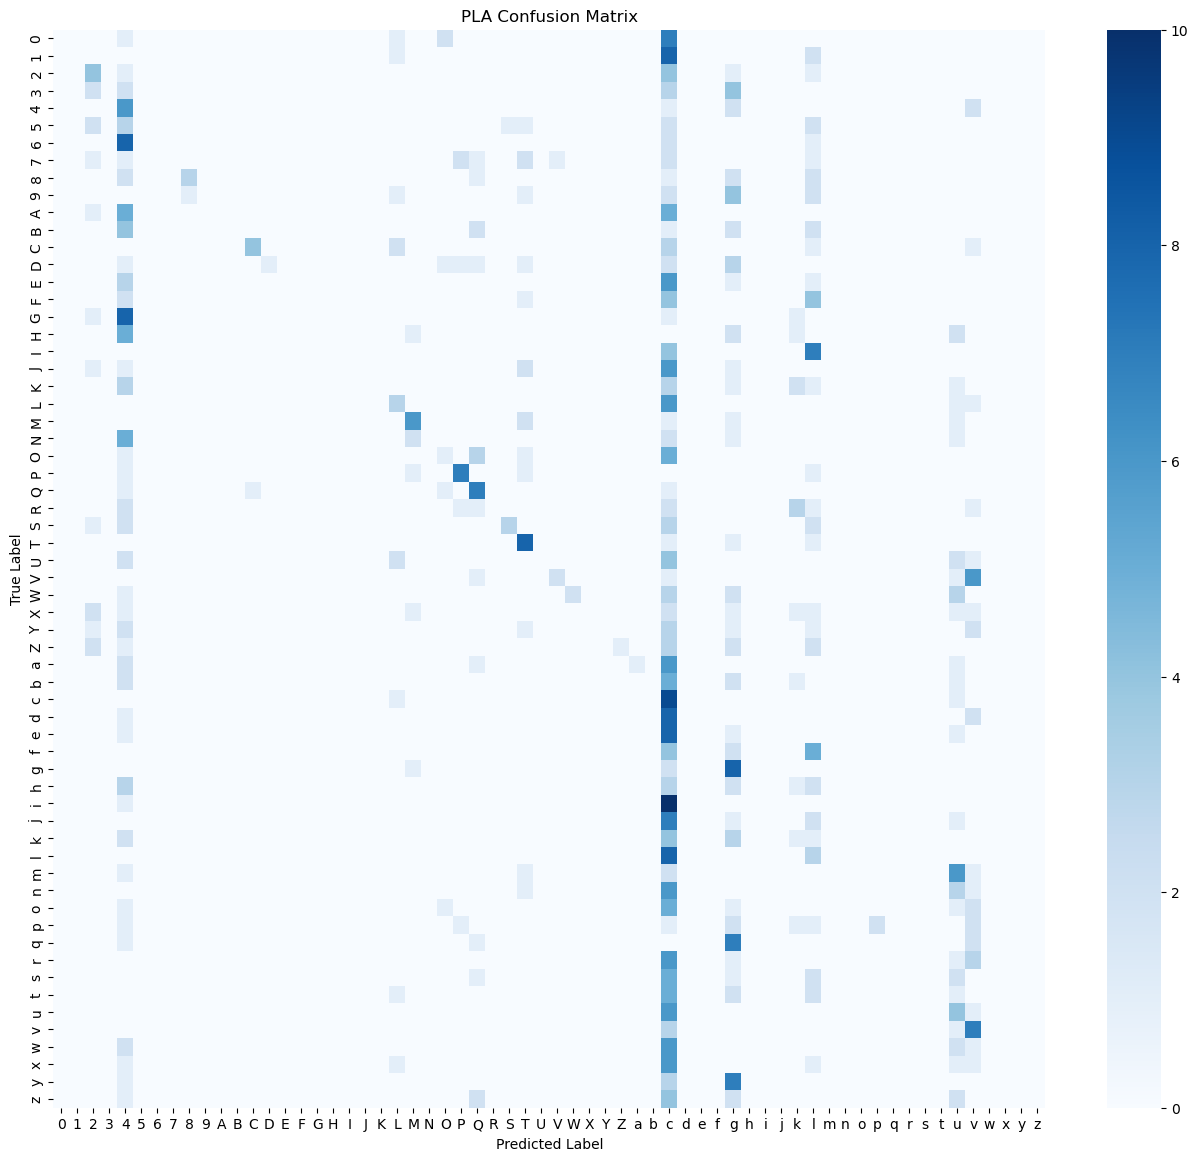

In [11]:
from sklearn.metrics import confusion_matrix

cm_pla = confusion_matrix(y_test, y_pred_pla)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_pla,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("PLA Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

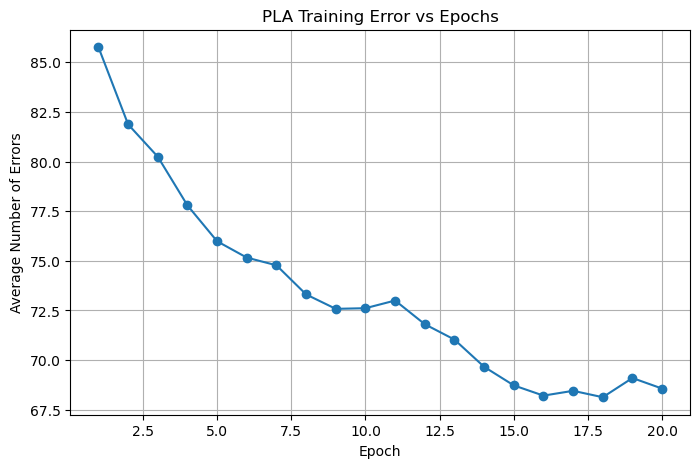

In [12]:
pla_error_history = np.array([
    model.errors for model in pla_models.values()
])

avg_pla_errors = pla_error_history.mean(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(avg_pla_errors) + 1),
    avg_pla_errors,
    marker="o"
)

plt.title("PLA Training Error vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Number of Errors")
plt.grid(True)
plt.show()

In [13]:
from sklearn.neural_network import MLPClassifier

mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=30,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=5
)

mlp_baseline.fit(X_train, y_train)

print("Baseline MLP training completed.")
print("Number of epochs:", mlp_baseline.n_iter_)

Baseline MLP training completed.
Number of epochs: 7


In [14]:
y_pred_mlp_base = mlp_baseline.predict(X_test)

mlp_base_accuracy = accuracy_score(y_test, y_pred_mlp_base)

mlp_base_precision = precision_score(
    y_test, y_pred_mlp_base, average="macro", zero_division=0
)

mlp_base_recall = recall_score(
    y_test, y_pred_mlp_base, average="macro", zero_division=0
)

mlp_base_f1 = f1_score(
    y_test, y_pred_mlp_base, average="macro", zero_division=0
)

mlp_baseline_results = pd.DataFrame({
    "Model": ["Baseline MLP"],
    "Accuracy": [mlp_base_accuracy],
    "Precision": [mlp_base_precision],
    "Recall": [mlp_base_recall],
    "F1-Score": [mlp_base_f1]
})

display(mlp_baseline_results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline MLP,0.013196,0.000392,0.013196,0.000758


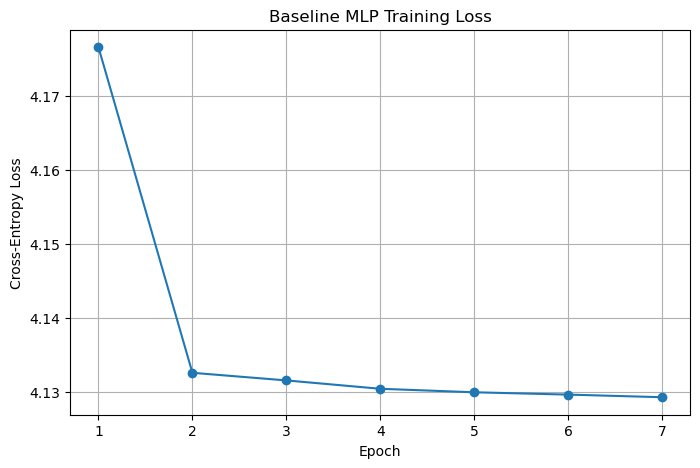

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(mlp_baseline.loss_curve_) + 1),
    mlp_baseline.loss_curve_,
    marker="o"
)

plt.title("Baseline MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()

In [16]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("Unique training classes:", len(np.unique(y_train)))
print("Unique test classes:", len(np.unique(y_test)))

print("\nPixel range:")
print(X_train.min(), "to", X_train.max())

print("\nClass distribution:")
print(pd.Series(y_train).value_counts().sort_index().head(10))

X_train: (2728, 784)
X_test : (682, 784)
Unique training classes: 62
Unique test classes: 62

Pixel range:
0.0 to 1.0

Class distribution:
0    44
1    44
2    44
3    44
4    44
5    44
6    44
7    44
8    44
9    44
Name: count, dtype: int64


In [17]:
print("Baseline MLP iterations:", mlp_baseline.n_iter_)
print("Final training loss:", mlp_baseline.loss_)

Baseline MLP iterations: 7
Final training loss: 4.129319053152906


In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

configs = [
    ("ReLU", "adam", 0.001, 32),
    ("ReLU", "adam", 0.01, 32),
    ("ReLU", "sgd", 0.001, 32),
    ("ReLU", "sgd", 0.01, 32),
    ("Tanh", "adam", 0.001, 32),
    ("Tanh", "adam", 0.01, 32),
    ("ReLU", "adam", 0.001, 64),
    ("ReLU", "adam", 0.01, 64)
]

tuning_results = []
trained_models = {}

for activation, optimizer, lr, batch_size in configs:
    
    print(
        f"Training: {activation}, {optimizer}, "
        f"lr={lr}, batch={batch_size}"
    )
    
    start_time = time.time()
    
    model = MLPClassifier(
        hidden_layer_sizes=(128,),
        activation=activation.lower(),
        solver=optimizer,
        learning_rate_init=lr,
        batch_size=batch_size,
        max_iter=40,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_val_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_val_pred)
    
    training_time = time.time() - start_time
    
    tuning_results.append({
        "Activation": activation,
        "Optimizer": optimizer.upper(),
        "Learning Rate": lr,
        "Batch Size": batch_size,
        "Epochs": model.n_iter_,
        "Accuracy": accuracy,
        "Training Time (s)": round(training_time, 2)
    })
    
    trained_models[
        (activation, optimizer, lr, batch_size)
    ] = model

tuning_df = pd.DataFrame(tuning_results)

display(
    tuning_df.sort_values(
        "Accuracy",
        ascending=False
    ).reset_index(drop=True)
)

Training: ReLU, adam, lr=0.001, batch=32
Training: ReLU, adam, lr=0.01, batch=32
Training: ReLU, sgd, lr=0.001, batch=32


D:\random_driver\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


Training: ReLU, sgd, lr=0.01, batch=32
Training: Tanh, adam, lr=0.001, batch=32


D:\random_driver\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


Training: Tanh, adam, lr=0.01, batch=32
Training: ReLU, adam, lr=0.001, batch=64


D:\random_driver\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


Training: ReLU, adam, lr=0.01, batch=64


,Activation,Optimizer,Learning Rate,Batch Size,Epochs,Accuracy,Training Time (s)
0,ReLU,SGD,0.001,32,40,0.250733,1.42
1,Tanh,ADAM,0.001,32,40,0.233138,2.18
2,ReLU,ADAM,0.001,64,40,0.057185,1.29
3,ReLU,ADAM,0.001,32,32,0.016129,1.85
4,ReLU,SGD,0.010,32,27,0.016129,0.92
5,ReLU,ADAM,0.010,32,27,0.016129,1.54
6,Tanh,ADAM,0.010,32,20,0.016129,1.10
7,ReLU,ADAM,0.010,64,27,0.016129,0.84


In [19]:
architecture_configs = [
    (128,),
    (128, 64)
]

architecture_results = []

for architecture in architecture_configs:
    
    print(f"Training architecture: {architecture}")
    
    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        batch_size=32,
        max_iter=40,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    architecture_results.append({
        "Hidden Layers": len(architecture),
        "Architecture": str(architecture),
        "Accuracy": accuracy_score(y_test, predictions),
        "Epochs": model.n_iter_
    })

architecture_df = pd.DataFrame(architecture_results)

display(architecture_df)

Training architecture: (128,)
Training architecture: (128, 64)


D:\random_driver\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


,Hidden Layers,Architecture,Accuracy,Epochs
0,1,"(128,)",0.016129,32
1,2,"(128, 64)",0.328446,40


In [20]:
two_layer_configs = [
    ("ReLU", "adam", 0.001, 32),
    ("ReLU", "adam", 0.001, 64),
    ("Tanh", "adam", 0.001, 32),
    ("ReLU", "sgd", 0.01, 32)
]

two_layer_results = []
two_layer_models = {}

for activation, optimizer, lr, batch_size in two_layer_configs:

    print(
        f"Training: {activation}, {optimizer}, "
        f"lr={lr}, batch={batch_size}"
    )

    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation=activation.lower(),
        solver=optimizer,
        learning_rate_init=lr,
        batch_size=batch_size,
        max_iter=60,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    result = {
        "Activation": activation,
        "Optimizer": optimizer.upper(),
        "Learning Rate": lr,
        "Batch Size": batch_size,
        "Hidden Layers": "(128, 64)",
        "Epochs": model.n_iter_,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, predictions, average="macro", zero_division=0
        )
    }

    two_layer_results.append(result)
    two_layer_models[
        (activation, optimizer, lr, batch_size)
    ] = model

two_layer_df = pd.DataFrame(two_layer_results)

display(
    two_layer_df.sort_values(
        "Accuracy",
        ascending=False
    ).reset_index(drop=True)
)

Training: ReLU, adam, lr=0.001, batch=32


D:\random_driver\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


Training: ReLU, adam, lr=0.001, batch=64


D:\random_driver\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


Training: Tanh, adam, lr=0.001, batch=32


D:\random_driver\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


Training: ReLU, sgd, lr=0.01, batch=32


D:\random_driver\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


,Activation,Optimizer,Learning Rate,Batch Size,Hidden Layers,Epochs,Accuracy,Precision,Recall,F1-Score
0,ReLU,ADAM,0.001,64,"(128, 64)",60,0.357771,0.375751,0.357771,0.340333
1,ReLU,ADAM,0.001,32,"(128, 64)",60,0.335777,0.341553,0.335777,0.317762
2,Tanh,ADAM,0.001,32,"(128, 64)",60,0.184751,0.165712,0.184751,0.153846
3,ReLU,SGD,0.010,32,"(128, 64)",60,0.164223,0.244255,0.164223,0.161826


In [21]:
best_index = two_layer_df["Accuracy"].idxmax()
best_config = two_layer_df.loc[best_index]

best_key = (
    best_config["Activation"],
    best_config["Optimizer"].lower(),
    best_config["Learning Rate"],
    int(best_config["Batch Size"])
)

final_mlp = two_layer_models[best_key]

print("Selected MLP configuration:")
display(best_config.to_frame().T)

Selected MLP configuration:


,Activation,Optimizer,Learning Rate,Batch Size,Hidden Layers,Epochs,Accuracy,Precision,Recall,F1-Score
1,ReLU,ADAM,0.001,64,"(128, 64)",60,0.357771,0.375751,0.357771,0.340333


In [22]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training samples   :", X_train_final.shape[0])
print("Validation samples :", X_val.shape[0])
print("Test samples       :", X_test.shape[0])

Training samples   : 2182
Validation samples : 546
Test samples       : 682


In [23]:
final_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=64,
    max_iter=60,
    random_state=42
)

final_mlp.fit(X_train_final, y_train_final)

print("Final MLP training completed.")
print("Epochs:", final_mlp.n_iter_)
print("Final training loss:", final_mlp.loss_)

Final MLP training completed.
Epochs: 60
Final training loss: 2.5231847382815578


D:\random_driver\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


In [24]:
y_pred_mlp = final_mlp.predict(X_test)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

mlp_precision = precision_score(
    y_test, y_pred_mlp, average="macro", zero_division=0
)

mlp_recall = recall_score(
    y_test, y_pred_mlp, average="macro", zero_division=0
)

mlp_f1 = f1_score(
    y_test, y_pred_mlp, average="macro", zero_division=0
)

mlp_results = pd.DataFrame({
    "Model": ["Tuned MLP"],
    "Accuracy": [mlp_accuracy],
    "Precision": [mlp_precision],
    "Recall": [mlp_recall],
    "F1-Score": [mlp_f1]
})

display(mlp_results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Tuned MLP,0.290323,0.302909,0.290323,0.273397


In [25]:
comparison_df = pd.DataFrame([
    {
        "Model": "PLA",
        "Accuracy": pla_accuracy,
        "Precision": pla_precision,
        "Recall": pla_recall,
        "F1-Score": pla_f1
    },
    {
        "Model": "Tuned MLP",
        "Accuracy": mlp_accuracy,
        "Precision": mlp_precision,
        "Recall": mlp_recall,
        "F1-Score": mlp_f1
    }
])

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,PLA,0.136364,0.176802,0.136364,0.102543
1,Tuned MLP,0.290323,0.302909,0.290323,0.273397


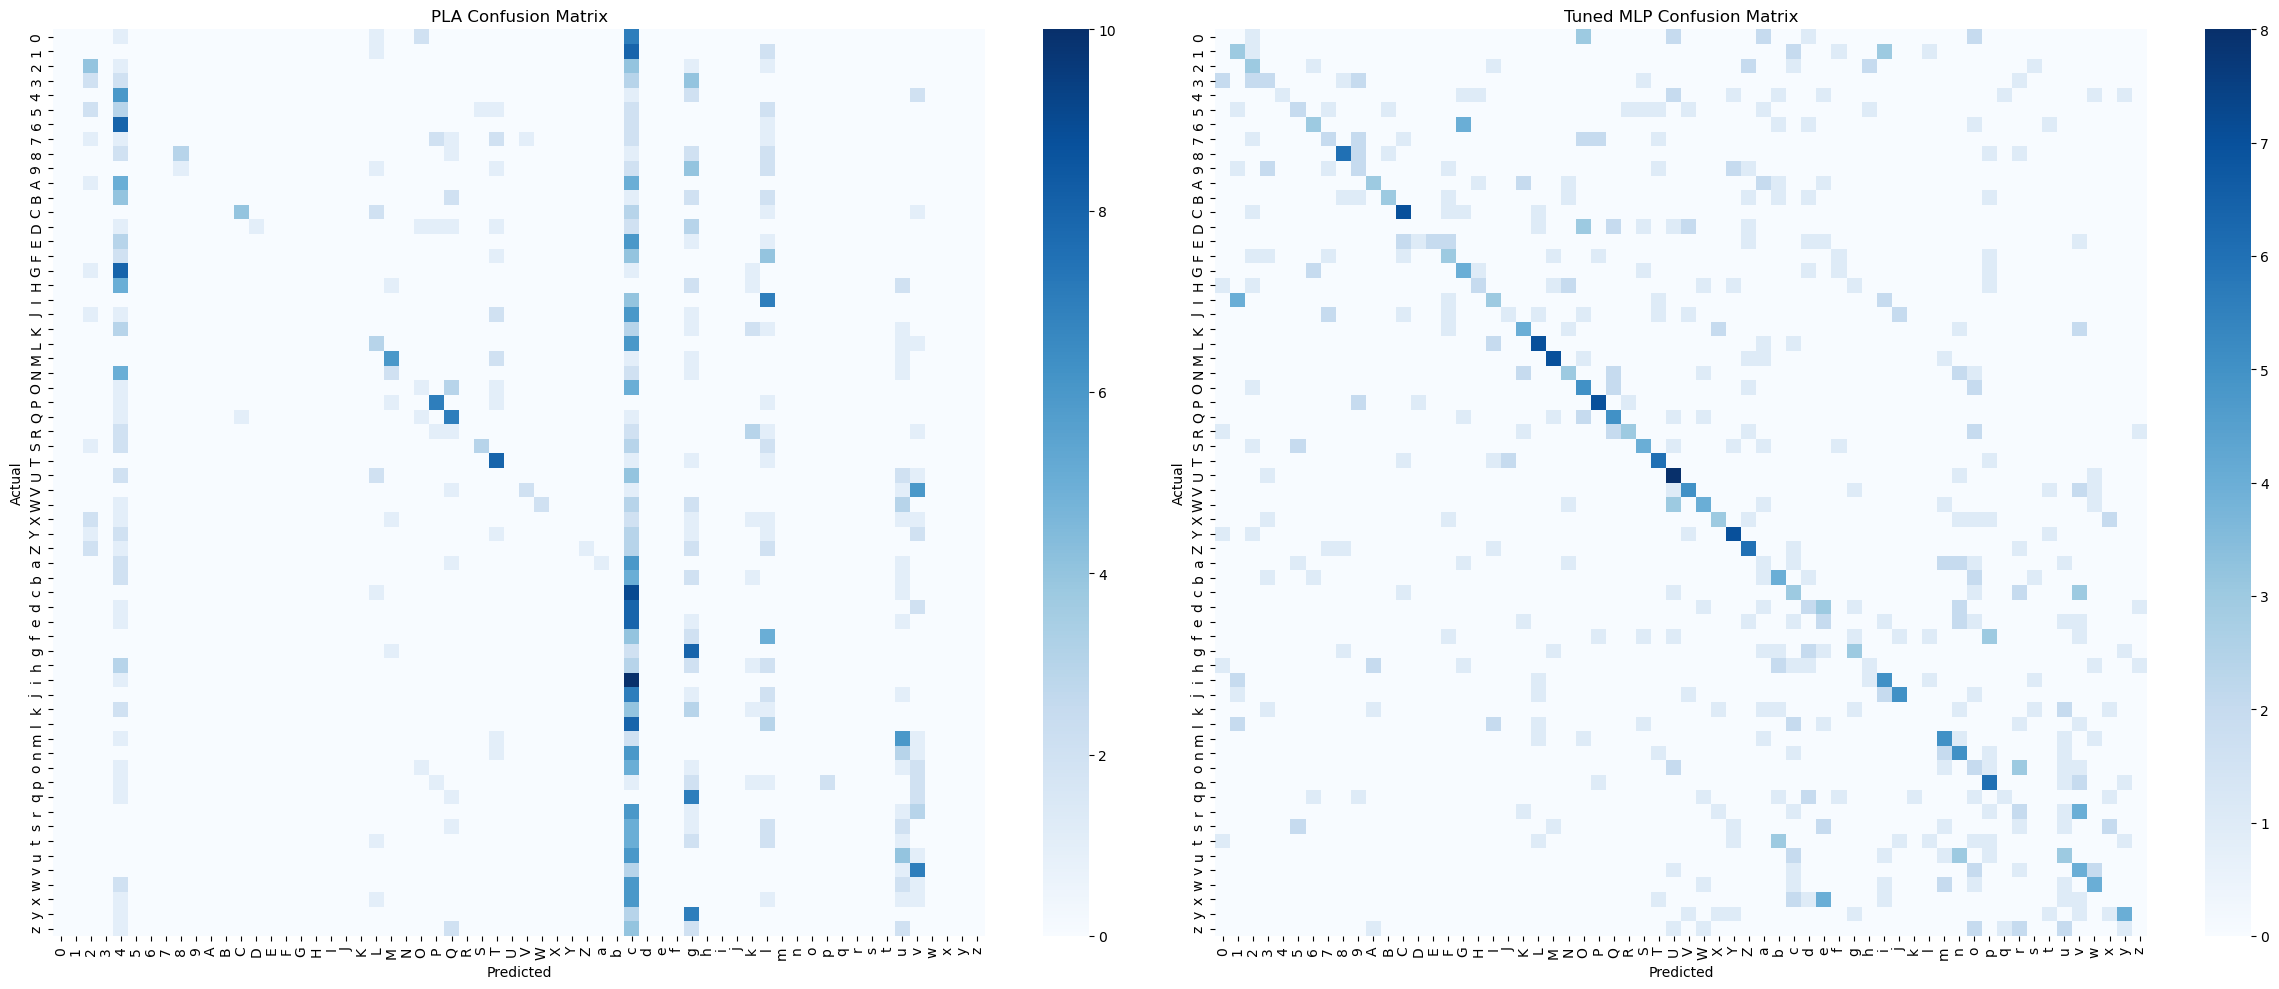

In [26]:
cm_pla = confusion_matrix(y_test, y_pred_pla)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(
    cm_pla,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[0]
)
axes[0].set_title("PLA Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_mlp,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[1]
)
axes[1].set_title("Tuned MLP Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(len(label_encoder.classes_))
)

# PLA decision scores
pla_scores = []

for cls in sorted(pla_models.keys()):
    model = pla_models[cls]
    score = np.dot(X_test, model.weights) + model.bias
    pla_scores.append(score)

pla_scores = np.array(pla_scores).T

# MLP probability scores
mlp_scores = final_mlp.predict_proba(X_test)

print("PLA scores shape:", pla_scores.shape)
print("MLP scores shape:", mlp_scores.shape)

PLA scores shape: (682, 62)
MLP scores shape: (682, 62)


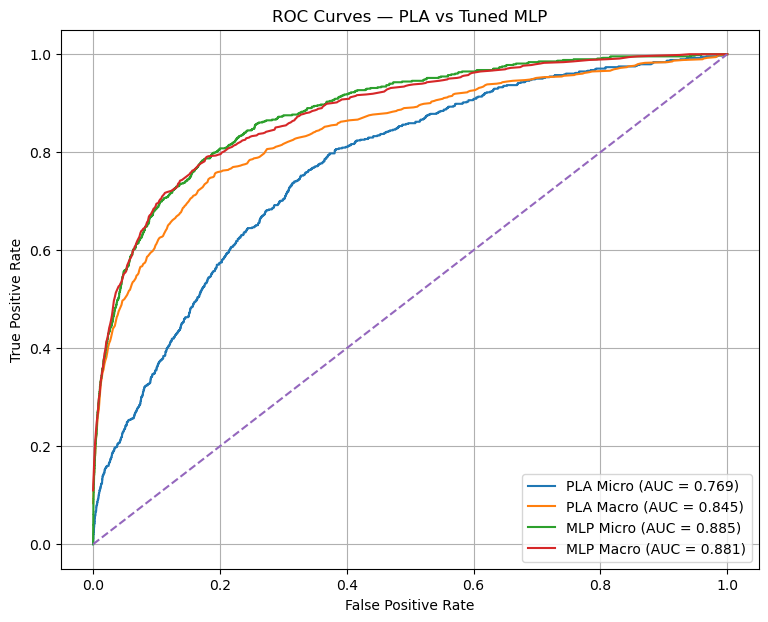

In [28]:
def plot_multiclass_roc(y_true_bin, scores, title):
    n_classes = y_true_bin.shape[1]

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(
            y_true_bin[:, i],
            scores[:, i]
        )
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_bin.ravel(),
        scores.ravel()
    )
    roc_auc["micro"] = auc(
        fpr["micro"],
        tpr["micro"]
    )

    # Macro-average
    all_fpr = np.unique(
        np.concatenate([fpr[i] for i in range(n_classes)])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(
        fpr["macro"],
        tpr["macro"]
    )

    return fpr, tpr, roc_auc


pla_fpr, pla_tpr, pla_auc = plot_multiclass_roc(
    y_test_bin,
    pla_scores,
    "PLA"
)

mlp_fpr, mlp_tpr, mlp_auc = plot_multiclass_roc(
    y_test_bin,
    mlp_scores,
    "MLP"
)

plt.figure(figsize=(9, 7))

plt.plot(
    pla_fpr["micro"],
    pla_tpr["micro"],
    label=f"PLA Micro (AUC = {pla_auc['micro']:.3f})"
)

plt.plot(
    pla_fpr["macro"],
    pla_tpr["macro"],
    label=f"PLA Macro (AUC = {pla_auc['macro']:.3f})"
)

plt.plot(
    mlp_fpr["micro"],
    mlp_tpr["micro"],
    label=f"MLP Micro (AUC = {mlp_auc['micro']:.3f})"
)

plt.plot(
    mlp_fpr["macro"],
    mlp_tpr["macro"],
    label=f"MLP Macro (AUC = {mlp_auc['macro']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — PLA vs Tuned MLP")
plt.legend()
plt.grid(True)
plt.show()

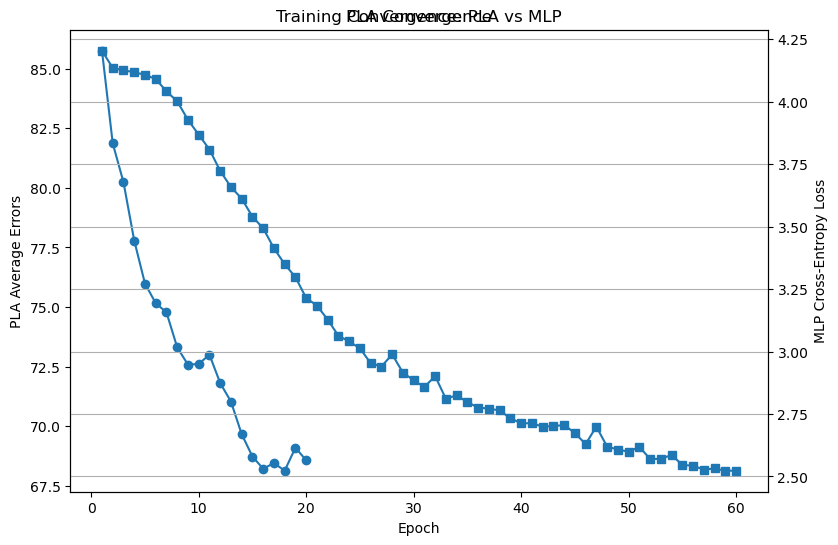

In [29]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(1, len(avg_pla_errors) + 1),
    avg_pla_errors,
    marker="o",
    label="PLA Training Errors"
)

plt.xlabel("Epoch")
plt.ylabel("PLA Average Errors")
plt.title("PLA Convergence")

plt.twinx()

plt.plot(
    range(1, len(final_mlp.loss_curve_) + 1),
    final_mlp.loss_curve_,
    marker="s",
    label="MLP Training Loss"
)

plt.ylabel("MLP Cross-Entropy Loss")

plt.title("Training Convergence: PLA vs MLP")
plt.grid(True)

plt.show()

In [30]:
final_hyperparameters = pd.DataFrame({
    "Parameter": [
        "Input Features",
        "Hidden Layers",
        "Neurons",
        "Activation",
        "Loss Function",
        "Optimizer",
        "Learning Rate",
        "Batch Size",
        "Maximum Epochs"
    ],
    "Value": [
        X_train.shape[1],
        2,
        "(128, 64)",
        "ReLU",
        "Cross-Entropy",
        "Adam",
        0.001,
        64,
        60
    ]
})

display(final_hyperparameters)

,Parameter,Value
0,Input Features,784
1,Hidden Layers,2
2,Neurons,"(128, 64)"
3,Activation,ReLU
4,Loss Function,Cross-Entropy
5,Optimizer,Adam
6,Learning Rate,0.001
7,Batch Size,64
8,Maximum Epochs,60
